# Statistical Comparison — Group A vs J
Boxplots interactifs et tests Mann-Whitney U pour chaque feature acoustique.
Un p-value < 0.05 indique une différence significative entre les groupes.

In [1]:
import os
import json
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

In [2]:
outputs_folder = "../outputs"
data = []
for sound_folder in os.listdir(outputs_folder):
    json_path = os.path.join(outputs_folder, sound_folder, "results.json")
    if os.path.exists(json_path):
        with open(json_path, "r") as f:
            result = json.load(f)
            result["group"] = sound_folder[0]
            data.append(result)

df = pd.DataFrame(data)
print(f"✓ {len(df)} sons chargés")

✓ 52 sons chargés


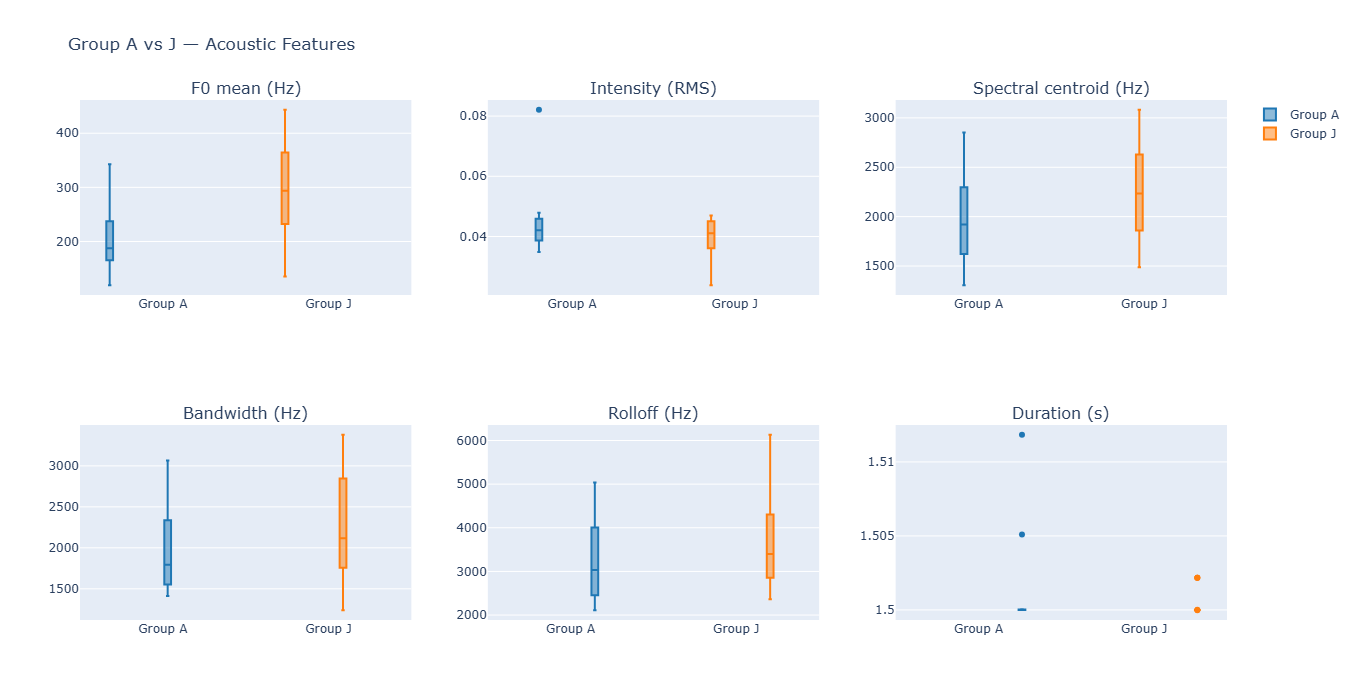

In [3]:
features_stats = {
    "F0 mean (Hz)":           "f0_mean",
    "Intensity (RMS)":         "global_intensity",
    "Spectral centroid (Hz)":  "spectral_centroid_mean",
    "Bandwidth (Hz)":          "spectral_bandwidth_mean",
    "Rolloff (Hz)":            "spectral_rolloff_mean",
    "Duration (s)":            "duration",
}

fig = make_subplots(rows=2, cols=3, subplot_titles=list(features_stats.keys()))

for i, (label, col) in enumerate(features_stats.items()):
    r, c = divmod(i, 3)
    for grp, color in [("A", "#1f77b4"), ("J", "#ff7f0e")]:
        vals = df[df["group"] == grp][col].values
        fig.add_trace(
            go.Box(y=vals, name=f"Group {grp}", marker_color=color,
                   showlegend=(i == 0)),
            row=r+1, col=c+1
        )

fig.update_layout(height=700, title="Group A vs J — Acoustic Features", boxmode="group")
fig.show()

## Tests Mann-Whitney U

In [4]:
results = []
for label, col in features_stats.items():
    a = df[df["group"] == "A"][col].values
    j = df[df["group"] == "J"][col].values
    _, p = mannwhitneyu(a, j, alternative="two-sided")
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    results.append({
        "Feature": label,
        "Mean A": round(a.mean(), 3),
        "Mean J": round(j.mean(), 3),
        "p-value": round(p, 4),
        "Sig.": sig
    })

pd.DataFrame(results)

,Feature,Mean A,Mean J,p-value,Sig.
0,F0 mean (Hz),203.678,299.613,0.0001,***
1,Intensity (RMS),0.044,0.040,0.2306,ns
2,Spectral centroid (Hz),1968.484,2244.300,0.0471,*
3,Bandwidth (Hz),1943.847,2245.380,0.0870,ns
4,Rolloff (Hz),3277.685,3672.406,0.1311,ns
5,Duration (s),1.501,1.500,0.2437,ns
